# State Preparation Use Case

This notebook demonstrates three state-preparation scenarios (GHZ, uniform superposition, and W) compiled by LEQO and executed with Qiskit.

## Workflow

1. Load model files for each state type.
2. Call `POST /debug/compile` for each model.
3. Capture OpenQASM output.
4. Execute with Qiskit Aer and inspect distributions.

In [1]:
import json
from pathlib import Path

import requests
from IPython.display import display
from qiskit import QuantumCircuit, qasm3, transpile
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator

In [ ]:
BASE_URL = "http://localhost:8000"
COMPILE_URL = f"{BASE_URL}/debug/compile"

USE_CASE_DIR = Path.cwd()
if not (USE_CASE_DIR / "ghz_3q.json").exists():
    USE_CASE_DIR = Path("/02-state-preparation")

MODEL_FILES = [
    USE_CASE_DIR / "ghz_3q.json",
    USE_CASE_DIR / "uniform_4q.json",
    USE_CASE_DIR / "w_3q.json",
]
MODEL_FILES

In [3]:
def compile_model(model_path: Path) -> tuple[dict, str]:
    payload = json.loads(model_path.read_text(encoding="utf-8"))
    response = requests.post(COMPILE_URL, json=payload, timeout=120)
    response.raise_for_status()

    content_type = response.headers.get("content-type", "")
    if "application/json" in content_type:
        raise RuntimeError(f"Unexpected JSON response: {response.json()}")

    return payload, response.text


compiled_models: dict[str, dict] = {}
for model_path in MODEL_FILES:
    payload, qasm_text = compile_model(model_path)
    compiled_models[model_path.stem] = {"payload": payload, "qasm": qasm_text}
    print(f"{model_path.name}: {len(qasm_text.splitlines())} QASM lines")

ghz_3q.json: 20 QASM lines
uniform_4q.json: 21 QASM lines
w_3q.json: 64 QASM lines


In [4]:
sample_name = next(iter(compiled_models))
print(f"Sample OpenQASM from {sample_name}:")
print("\n".join(compiled_models[sample_name]["qasm"].splitlines()[:40]))

Sample OpenQASM from ghz_3q:
OPENQASM 3.1;
include "stdgates.inc";
qubit[3] leqo_reg;
/* Start node prepare */
let leqo_aa3a7f547f5f5337872930f6b38a8308_state = leqo_reg[{0, 1, 2}];
h leqo_aa3a7f547f5f5337872930f6b38a8308_state[0];
cx leqo_aa3a7f547f5f5337872930f6b38a8308_state[0], leqo_aa3a7f547f5f5337872930f6b38a8308_state[1];
cx leqo_aa3a7f547f5f5337872930f6b38a8308_state[0], leqo_aa3a7f547f5f5337872930f6b38a8308_state[2];
@leqo.output 0
let leqo_aa3a7f547f5f5337872930f6b38a8308_state_out = leqo_aa3a7f547f5f5337872930f6b38a8308_state;
/* End node prepare */
/* Start node measure */
@leqo.input 0
let leqo_4983cc78a037571ca3ca46051929624b_q = leqo_reg[{0, 1, 2}];
bit[3] leqo_4983cc78a037571ca3ca46051929624b_result = measure leqo_4983cc78a037571ca3ca46051929624b_q[{0, 1, 2}];
@leqo.output 0
let leqo_4983cc78a037571ca3ca46051929624b_out = leqo_4983cc78a037571ca3ca46051929624b_result;
@leqo.output 1
let leqo_4983cc78a037571ca3ca46051929624b_qubit_out = leqo_4983cc78a037571ca3ca4605192962

## Execute with Qiskit

In [5]:
def circuit_from_qasm(qasm_text: str) -> QuantumCircuit:
    qc = qasm3.loads(qasm_text)
    return qc


ghz_3q | counts={'000 ': 2078, '111 ': 2018}


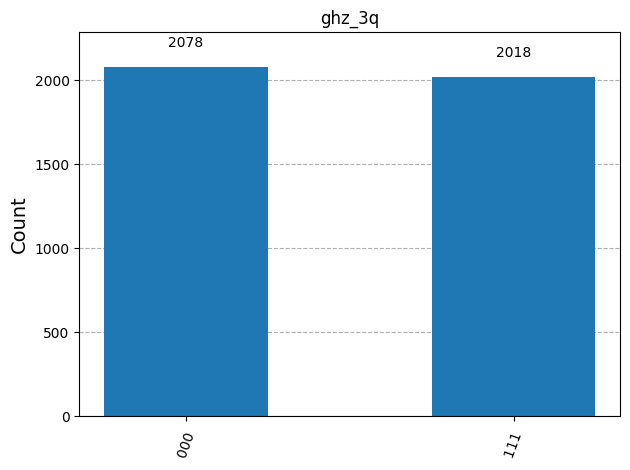

uniform_4q | counts={'0000 ': 291, '0010 ': 266, '0111 ': 235, '1010 ': 223, '0101 ': 274, '1000 ': 268, '1110 ': 269, '1011 ': 227, '0001 ': 223, '0011 ': 276, '1101 ': 279, '1111 ': 258, '1001 ': 259, '1100 ': 248, '0100 ': 251, '0110 ': 249}


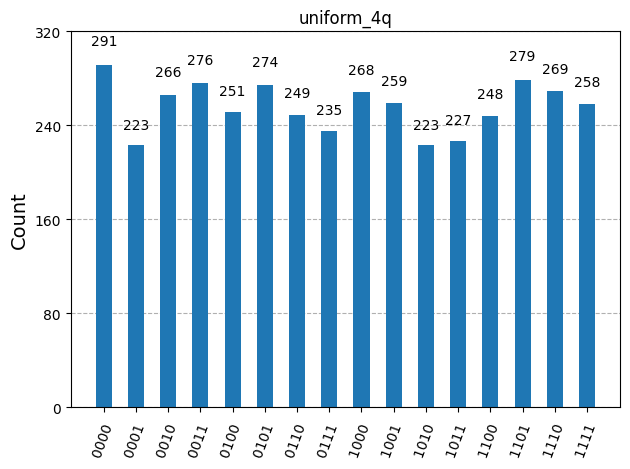

w_3q | counts={'001 ': 1397, '010 ': 1380, '100 ': 1319}


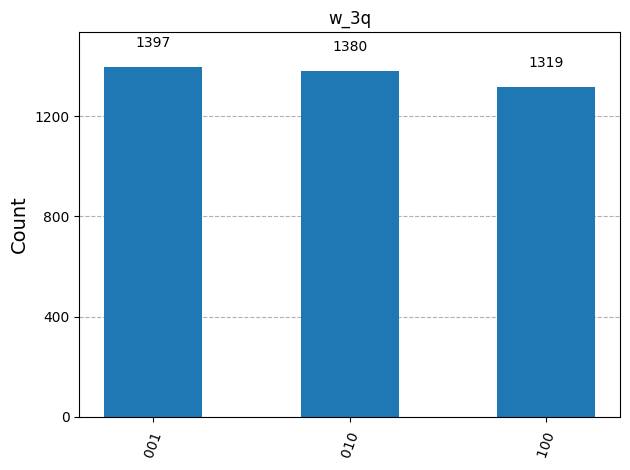

In [6]:
simulator = AerSimulator()
shots = 4096
counts_by_model: dict[str, dict[str, int]] = {}

for name, artifact in compiled_models.items():
    qc = circuit_from_qasm(artifact["qasm"])
    tqc = transpile(qc, simulator)
    counts = simulator.run(tqc, shots=shots).result().get_counts()
    counts_by_model[name] = counts

    print(f"{name} | counts={counts}")
    display(plot_histogram(counts, title=name))


In [7]:
for name, counts in counts_by_model.items():
    total = sum(counts.values())
    normalized = {k: round(v / total, 4) for k, v in sorted(counts.items())}
    print(f"{name}: {normalized}")

ghz_3q: {'000 ': 0.5073, '111 ': 0.4927}
uniform_4q: {'0000 ': 0.071, '0001 ': 0.0544, '0010 ': 0.0649, '0011 ': 0.0674, '0100 ': 0.0613, '0101 ': 0.0669, '0110 ': 0.0608, '0111 ': 0.0574, '1000 ': 0.0654, '1001 ': 0.0632, '1010 ': 0.0544, '1011 ': 0.0554, '1100 ': 0.0605, '1101 ': 0.0681, '1110 ': 0.0657, '1111 ': 0.063}
w_3q: {'001 ': 0.3411, '010 ': 0.3369, '100 ': 0.322}


Expected qualitative behavior:

- `ghz_3q`: dominant `000` and `111`
- `uniform_4q`: close-to-uniform across all 16 outcomes
- `w_3q`